<a href="https://colab.research.google.com/github/cjlantigua-hue/gmp-audit-risk-dashboard/blob/main/noteboo/01_generate_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GMP Audit Findings Risk Dashboard
## Purpose
The purpose of this project is to create a dashboard that scores audit findings by severity, recurrence, process area, and remediation status in the pharmaceutical industry.

## Business Value
To help QA leadership prioritize inspection readiness activities.

## Techniques
* Risk Scoring
* Trend Analysis
* Pareto Analysis
* Power BI / Tableau Dashboard
* Optional ML model for high risk finding prediction

# Note:
This project consists of (0 - 8)phases:

0. Set up of workspace
1. Learn the domain and define the data model
2. Generate synthetic data
3. Build the risk scoring model
4. Exploratory, trend, and Pareto Analysis
5. Build the dashboard
6. Optional ML model
7. Dashboard Deployment
8. Package for my portfolio

Phases 0 and 1 are completed. This notebook will start in phase 2.
## Phase 2:
Generate synthetic data. This notebook produces a CSV of synthetic audit findings saved to data/

# 01 · Generate Synthetic Data
**Project:** GMP Audit Findings Risk Dashboard · **Company:** Meridian Pharma (fictional)

This notebook generates the four tables defined in `docs/data_dictionary.md`:
**sites → audits → findings → capas**, covering **2023-10-01 to 2026-09-30**, with a fixed
**snapshot date of 2026-09-30**.

All data is **synthetic**. Patterns are planted on purpose so the analysis in later phases has
something real to find (see Section 3 and the verification in Section 9).

**How to run:** `Runtime → Run all`. A fixed random seed means every run produces identical data.
Outputs are saved to Google Drive in `gmp-audit-risk-dashboard/data/raw/`.

## 1. Setup

In [ ]:
!pip install faker -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker

# Mount Google Drive when running in Colab, so outputs survive runtime resets
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT = '/content/drive/MyDrive/gmp-audit-risk-dashboard'
except ImportError:          # running locally instead of Colab
    PROJECT = './gmp-audit-risk-dashboard'

RAW_DIR = f'{PROJECT}/data/raw'
os.makedirs(RAW_DIR, exist_ok=True)
print('Saving outputs to:', RAW_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.4 MB/s eta 0:00:00
Mounted at /content/drive
Saving outputs to: /content/drive/MyDrive/gmp-audit-risk-dashboard/data/raw


## 2. Configuration
Every knob that shapes the data lives here. Change a value and rerun to see how the dataset responds.

In [ ]:
SEED = 42
rng = np.random.default_rng(SEED)
Faker.seed(SEED)
fake = Faker()

START    = pd.Timestamp('2023-10-01')
END      = pd.Timestamp('2026-09-30')
SNAPSHOT = pd.Timestamp('2026-09-30')   # "today" for all open/overdue calculations

# --- Audit schedule (per site, over the 3-year window) ---
INTERNAL_AUDITS_PER_SITE  = 24          # roughly every 6 weeks
CORPORATE_AUDITS_PER_SITE = 6           # roughly twice a year
REGULATORY_MEAN_PER_SITE  = 3           # Poisson mean; at least 1 per site

# --- Findings per audit (Poisson means, before site/trend multipliers) ---
FINDINGS_MEAN = {'Internal': 8, 'Corporate': 10, 'Regulatory': 5}

# --- Planted pattern: trends ---
IMPROVING_SITE, REMEDIATION_START = 'S02', pd.Timestamp('2025-04-01')
IMPROVING_BEFORE, IMPROVING_AFTER = 1.35, 0.70      # finding-rate multipliers
WORSENING_SITE = 'S01'
WORSENING_FROM, WORSENING_TO = 0.70, 1.70           # linear ramp across the window

# --- Planted pattern: problem site ---
PROBLEM_SITE      = 'S03'
PROBLEM_DI_MULT   = 3.0    # data-integrity category weight multiplier
PROBLEM_CLOSE_MULT = 1.35  # slower CAPA closure
PROBLEM_FAIL_RATE  = 0.25  # effectiveness-check failure rate (vs 0.12 elsewhere)

# --- Planted pattern: recurrence ---
# A repeat = same site + same category + same affected item, within the window (rule 5.4)
RECURRENCE_WINDOW_DAYS = 730
CATEGORY_HISTORY_BOOST = 0.25  # categories cited recently at a site become a bit more common
ITEM_REPEAT_BOOST      = 0.4   # item weight x (1 + 0.4 x prior count, capped at 3)
FAILED_CAPA_BOOST      = 5.0   # item weight multiplier if its prior CAPA failed the effectiveness check

# --- CAPA timing ---
DUE_DAYS = {'Critical': 30, 'Major': 60, 'Minor': 90}
CLOSE_MEDIAN_FRACTION = 0.65   # median close time = 65% of allowed days
CLOSE_SIGMA           = 0.35   # lognormal spread
STALL_RATE, STALL_MULT = 0.04, 3.0   # a few CAPAs stall badly
BASE_FAIL_RATE = 0.12

## 3. Reference data
Values match Sections 3.1 and 4 of the data dictionary.

**Category weights** create the Pareto skew: five categories carry most of the volume.

In [ ]:
sites = pd.DataFrame([
    ('S01', 'Raleigh, NC',        'Sterile Injectables', 'North America'),
    ('S02', 'San Juan, PR',       'Oral Solid Dose',     'North America'),
    ('S03', 'Cork, Ireland',      'API',                 'Europe'),
    ('S04', 'Basel, Switzerland', 'Sterile Injectables', 'Europe'),
    ('S05', 'Hyderabad, India',   'Oral Solid Dose',     'Asia'),
], columns=['site_id', 'site_name', 'product_type', 'region'])

# (process_area, category, cfr_reference, base_weight)
CATEGORIES = [
    ('Quality System', 'Inadequate deviation investigation',       '211.192',    12),
    ('Quality System', 'Ineffective CAPA',                         '211.192',     3),
    ('Quality System', 'Change control deficiency',                '211.100(a)',  2),
    ('Quality System', 'Inadequate QC unit oversight',             '211.22',      1),
    ('Quality System', 'Complaint handling deficiency',            '211.198',     0.8),
    ('Quality System', 'Annual product review incomplete',         '211.180(e)',  0.8),
    ('Quality System', 'Training deficiency',                      '211.25',      7),
    ('Facilities & Equipment', 'Equipment cleaning / cleaning validation', '211.67', 6.5),
    ('Facilities & Equipment', 'Equipment calibration / maintenance', '211.68(a)', 1.5),
    ('Facilities & Equipment', 'Facility maintenance',             '211.58',      1),
    ('Facilities & Equipment', 'Environmental monitoring',         '211.42(c)',   1),
    ('Facilities & Equipment', 'Computerized system / data integrity', '211.68(b)', 1.8),
    ('Materials', 'Component testing / supplier qualification',    '211.84',      1),
    ('Materials', 'Material storage and handling',                 '211.80',      0.8),
    ('Production', 'Batch record documentation (GDP)',             '211.188',    15),
    ('Production', 'Procedures not followed',                      '211.100(b)',  9),
    ('Production', 'In-process control deficiency',                '211.110',     1),
    ('Packaging & Labeling', 'Label control / reconciliation',     '211.125',     0.8),
    ('Packaging & Labeling', 'Line clearance deficiency',          '211.130',     0.8),
    ('Laboratory Controls', 'Inadequate OOS investigation',        '211.192',     1.8),
    ('Laboratory Controls', 'Method validation deficiency',        '211.165(e)',  0.6),
    ('Laboratory Controls', 'Stability program deficiency',        '211.166',     0.8),
    ('Laboratory Controls', 'Laboratory records / data integrity', '211.194',     1.5),
    ('Laboratory Controls', 'Lab instrument calibration',          '211.160(b)',  0.8),
]
cat_df = pd.DataFrame(CATEGORIES, columns=['process_area', 'category', 'cfr_reference', 'base_weight'])
CAT_NAMES = cat_df['category'].tolist()
CAT_AREA  = dict(zip(cat_df.category, cat_df.process_area))
CAT_CFR   = dict(zip(cat_df.category, cat_df.cfr_reference))

DI_CATS = {'Computerized system / data integrity', 'Laboratory records / data integrity'}
HIGH_RISK_CATS = DI_CATS | {'Inadequate OOS investigation', 'Inadequate deviation investigation',
                            'Equipment cleaning / cleaning validation', 'Environmental monitoring'}
LOW_RISK_CATS  = {'Annual product review incomplete', 'Facility maintenance',
                  'Material storage and handling', 'Training deficiency'}

def site_category_weights(site_id, product_type):
    # Category weights adjusted for what each site makes
    w = cat_df['base_weight'].to_numpy(dtype=float).copy()
    for i, c in enumerate(CAT_NAMES):
        if product_type == 'Sterile Injectables' and c == 'Environmental monitoring':
            w[i] *= 4          # aseptic sites get far more EM findings
        if product_type == 'API' and CAT_AREA[c] == 'Packaging & Labeling':
            w[i] *= 0.3        # API sites do little packaging
        if site_id == PROBLEM_SITE and c in DI_CATS:
            w[i] *= PROBLEM_DI_MULT
    return w

SITE_WEIGHTS = {r.site_id: site_category_weights(r.site_id, r.product_type) for r in sites.itertuples()}
print(cat_df[['process_area', 'category', 'cfr_reference']].to_string(index=False))

          process_area                                   category cfr_reference
        Quality System         Inadequate deviation investigation       211.192
        Quality System                           Ineffective CAPA       211.192
        Quality System                  Change control deficiency    211.100(a)
        Quality System               Inadequate QC unit oversight        211.22
        Quality System              Complaint handling deficiency       211.198
        Quality System           Annual product review incomplete    211.180(e)
        Quality System                        Training deficiency        211.25
Facilities & Equipment   Equipment cleaning / cleaning validation        211.67
Facilities & Equipment        Equipment calibration / maintenance     211.68(a)
Facilities & Equipment                       Facility maintenance        211.58
Facilities & Equipment                   Environmental monitoring     211.42(c)
Facilities & Equipment       Computerize

### Affected items
Every finding concerns one specific **affected item**: a piece of equipment, a lab instrument, a room,
a product, or a department. The category decides which kind of item it is. Each site has its own
asset register, matched to what it makes (no tablet presses at a sterile site).

Recurrence (rule 5.4) is judged at this level: the same problem on the same item at the same site.

In [ ]:
ITEM_TYPE = {   # category -> kind of affected item
    'Inadequate deviation investigation': 'product', 'Ineffective CAPA': 'department',
    'Change control deficiency': 'equipment',         'Inadequate QC unit oversight': 'department',
    'Complaint handling deficiency': 'product',       'Annual product review incomplete': 'product',
    'Training deficiency': 'department',              'Equipment cleaning / cleaning validation': 'equipment',
    'Equipment calibration / maintenance': 'equipment', 'Facility maintenance': 'room',
    'Environmental monitoring': 'room',               'Computerized system / data integrity': 'equipment',
    'Component testing / supplier qualification': 'product', 'Material storage and handling': 'room',
    'Batch record documentation (GDP)': 'product',    'Procedures not followed': 'department',
    'In-process control deficiency': 'equipment',     'Label control / reconciliation': 'product',
    'Line clearance deficiency': 'product',           'Inadequate OOS investigation': 'instrument',
    'Method validation deficiency': 'instrument',     'Stability program deficiency': 'product',
    'Laboratory records / data integrity': 'instrument', 'Lab instrument calibration': 'instrument',
}
assert set(ITEM_TYPE) == set(CAT_NAMES)

EQUIPMENT_BY_TYPE = {
    'Sterile Injectables': ['filling line FL-1', 'filling line FL-2', 'lyophilizer LY-01', 'lyophilizer LY-02',
        'autoclave AC-01', 'autoclave AC-02', 'isolator ISO-03', 'vial washer VW-01', 'depyrogenation tunnel DT-01',
        'capping machine CM-02', 'CIP skid CIP-01', 'WFI system WFI-01', 'compounding tank CT-04', 'AHU-07'],
    'Oral Solid Dose': ['tablet press TP-01', 'tablet press TP-03', 'granulator GR-01', 'fluid bed dryer FBD-02',
        'blender BL-05', 'coating pan CP-02', 'encapsulator EN-01', 'blister line BL-L1', 'mill ML-02',
        'sifter SF-01', 'purified water PW-01', 'compression suite AHU-03', 'checkweigher CW-02', 'bottling line BT-01'],
    'API': ['reactor R-101', 'reactor R-201', 'reactor R-305', 'centrifuge CF-03', 'filter dryer FD-01',
        'crystallizer CR-02', 'vacuum dryer VD-04', 'distillation column DC-01', 'solvent recovery SR-02',
        'mill ML-05', 'purified water PW-02', 'nitrogen system N2-01', 'scrubber SC-01', 'DCS control system DCS-01'],
}
ROOMS_BY_TYPE = {
    'Sterile Injectables': ['Aseptic Core A', 'Aseptic Core B', 'Grade C prep room', 'Gowning room 2',
        'Component prep room', 'Warehouse Bay A', 'Cold room CR-1', 'QC micro lab', 'Visual inspection room', 'Corridor 1.2'],
    'Oral Solid Dose': ['Granulation Room 2', 'Compression Suite 2', 'Coating room 1', 'Dispensary',
        'Packaging Hall 1', 'Warehouse Bay C', 'QC Lab 3', 'Encapsulation room', 'Wash bay', 'Corridor 2.1'],
    'API': ['Reactor bay 1', 'Reactor bay 2', 'Isolation room', 'Drying room', 'Milling suite',
        'Solvent store', 'Warehouse Bay B', 'QC Lab 1', 'Sampling booth', 'Corridor 3.4'],
}
INSTRUMENTS = ['HPLC-07', 'HPLC-09', 'HPLC-12', 'HPLC-15', 'GC-03', 'GC-05', 'dissolution bath DB-02',
               'UV spectrophotometer UV-04', 'analytical balance BAL-15', 'KF titrator KF-02',
               'particle counter PC-01', 'FTIR-02']
DEPARTMENTS = ['Manufacturing', 'Packaging', 'QC Laboratory', 'Warehouse', 'Engineering',
               'Quality Assurance', 'Validation', 'Microbiology']
PRODUCTS_BY_SITE = {
    'S01': ['MRD-101', 'MRD-104', 'MRD-118', 'MRD-122', 'MRD-130', 'MRD-145', 'MRD-151', 'MRD-166'],
    'S02': ['MRD-214', 'MRD-221', 'MRD-236', 'MRD-240', 'MRD-257', 'MRD-263', 'MRD-278', 'MRD-289'],
    'S03': ['MRD-330 API', 'MRD-334 API', 'MRD-341 API', 'MRD-352 API', 'MRD-368 API', 'MRD-375 API'],
    'S04': ['MRD-452', 'MRD-457', 'MRD-460', 'MRD-471', 'MRD-486', 'MRD-490', 'MRD-495', 'MRD-499'],
    'S05': ['MRD-517', 'MRD-523', 'MRD-530', 'MRD-544', 'MRD-551', 'MRD-562', 'MRD-576', 'MRD-588'],
}

SITE_ITEMS = {}
for s in sites.itertuples():
    SITE_ITEMS[s.site_id] = {'equipment': EQUIPMENT_BY_TYPE[s.product_type], 'room': ROOMS_BY_TYPE[s.product_type],
                             'instrument': INSTRUMENTS, 'department': DEPARTMENTS,
                             'product': PRODUCTS_BY_SITE[s.site_id]}
print({k: len(v) for k, v in SITE_ITEMS['S01'].items()})

{'equipment': 14, 'room': 10, 'instrument': 12, 'department': 8, 'product': 8}


## 4. Finding description templates
Each category has its own templates so the text is realistic enough for NLP work later
(and ties in with the root cause classifier project). Placeholders are filled with Faker and the site's asset register, and the
finding's own affected item always appears in its description.

In [ ]:
STEPS       = ['line clearance', 'weighing and dispensing', 'in-process weight check', 'filter integrity test',
               'equipment setup', 'yield reconciliation', 'sampling']

TEMPLATES = {
 'Inadequate deviation investigation': [
   'Deviation {dev} for {product} batch {batch} was closed without identifying a root cause; the investigation concluded "human error" with no supporting analysis.',
   'Investigation of deviation {dev} did not assess impact on other batches of {product} manufactured on {equip}.',
   'Deviation {dev} on {product} was not initiated until {n} days after the event, exceeding the time limit in {sop}.'],
 'Ineffective CAPA': [
   'A CAPA addressing a prior {dept} finding was closed, but the same issue recurred in {n} subsequent events.',
   'The effectiveness check for a {dept} CAPA was limited to retraining and did not verify the fix worked.'],
 'Change control deficiency': [
   'A change to {equip} operating parameters was implemented before change control approval under {sop}.',
   'Change control for the {equip} software upgrade lacked a documented impact assessment on validation status.'],
 'Inadequate QC unit oversight': [
   'The quality unit approved release of batch {batch} before all {dept} deviations were closed.',
   'Quality unit review of {dept} procedure {sop} was not documented before it became effective.'],
 'Complaint handling deficiency': [
   'Product complaint for {product} was not evaluated for a possible link to an open deviation within the required {n} days.',
   'Complaint trend review for {product} was not performed as required by {sop}.'],
 'Annual product review incomplete': [
   'The annual product review for {product} did not include a review of all batches manufactured in the period.',
   'The annual product review for {product} omitted stability data and CAPA trend evaluation.'],
 'Training deficiency': [
   '{n} {dept} staff performed {step} without documented training on the current revision of {sop}.',
   'Training records for {dept} staff were not updated after the revision of {sop}.'],
 'Equipment cleaning / cleaning validation': [
   'Visible residue was observed on {equip} labeled as clean in {room}.',
   'Cleaning validation for {equip} did not cover the worst-case product {product}.',
   'Cleaning log for {equip} was missing entries for {n} cleaning cycles.'],
 'Equipment calibration / maintenance': [
   'Preventive maintenance for {equip} was overdue by {n} days while the equipment remained in use.',
   'Calibration status label on {equip} did not match the calibration records.'],
 'Facility maintenance': [
   'Damaged wall panels and peeling paint were observed in {room}.',
   'A ceiling leak in {room} was reported but no work order was raised for {n} days.'],
 'Environmental monitoring': [
   'Environmental monitoring excursions in {room} were not investigated in line with {sop}.',
   'Action-level microbial counts in {room} were recorded on {n} occasions without trend evaluation.'],
 'Computerized system / data integrity': [
   'Audit trail functionality on the {equip} control system was disabled.',
   'Shared login credentials were used on the {equip} HMI, preventing attribution of entries.',
   'Audit trail review for the {equip} control system was not performed before batch {batch} release.'],
 'Component testing / supplier qualification': [
   'Incoming raw material for {product} was released on the basis of a supplier CoA without identity testing.',
   'A supplier of a critical excipient for {product} was not requalified within the period required by {sop}.'],
 'Material storage and handling': [
   'Quarantined materials were stored alongside released materials in {room}.',
   'Temperature records for {room} showed excursions on {n} days with no impact assessment.'],
 'Batch record documentation (GDP)': [
   'Batch record for {product} batch {batch} lacked second-person verification for {step}.',
   'Batch record for {product} batch {batch} contained {n} corrections without initials, date, or justification.',
   'Entries in the batch record for {product} batch {batch} were recorded before the step was performed.'],
 'Procedures not followed': [
   '{dept} personnel performed {step} using a sequence different from {sop}.',
   '{dept} personnel performed {step} for batch {batch} without the verification required by {sop}.'],
 'In-process control deficiency': [
   'In-process checks for {product} on {equip} were performed at a lower frequency than specified.',
   'In-process control limits on {equip} were exceeded for batch {batch} without initiating a deviation.'],
 'Label control / reconciliation': [
   'Label reconciliation for {product} batch {batch} showed a discrepancy of {n} labels with no investigation.',
   'Obsolete labels for {product} were found in the active label store.'],
 'Line clearance deficiency': [
   'Line clearance before packaging {product} batch {batch} did not include verification of removal of prior product.',
   'Leftover printed components from a previous {product} run were found after line clearance was signed.'],
 'Inadequate OOS investigation': [
   'An out-of-specification assay result for {product} batch {batch} on {instr} was invalidated without a documented root cause.',
   'OOS investigation for batch {batch} retested the sample on {instr} {n} times until a passing result was obtained.'],
 'Method validation deficiency': [
   'The analytical method for {product} impurities on {instr} was not validated for robustness.',
   'Method transfer for {product} assay to {instr} lacked documented comparability data.'],
 'Stability program deficiency': [
   'Stability samples for {product} were pulled {n} days outside the protocol window.',
   'Stability protocol for {product} did not include the commercial container closure system.'],
 'Laboratory records / data integrity': [
   'Chromatograms on {instr} showed repeated injections that were not reported or explained.',
   'Analysts on {instr} had administrator rights allowing deletion of electronic data.',
   'Raw data for {product} testing on {instr} were recorded on uncontrolled worksheets.'],
 'Lab instrument calibration': [
   '{instr} was used for release testing {n} days after its calibration had expired.',
   'System suitability failures on {instr} were not investigated before results were reported.'],
}
assert set(TEMPLATES) == set(CAT_NAMES), 'Every category needs templates'
SLOT = {'product': '{product}', 'equipment': '{equip}', 'instrument': '{instr}', 'room': '{room}', 'department': '{dept}'}
for c, ts in TEMPLATES.items():
    for t in ts:
        assert SLOT[ITEM_TYPE[c]] in t, f'Template for {c} must mention its affected item: {t}'


def make_description(category, audit_date, site_id, item):
    # Random filler for every placeholder, then the finding's own affected item overrides its slot
    items = SITE_ITEMS[site_id]
    values = dict(
        dev=f'DEV-{audit_date.year}-{fake.numerify("####")}',
        batch=fake.bothify('B##-####'),
        sop=f'SOP-{rng.choice(["QA", "PR", "QC", "EN", "WH"])}-{fake.numerify("###")}',
        product=rng.choice(items['product']), equip=rng.choice(items['equipment']),
        instr=rng.choice(items['instrument']), room=rng.choice(items['room']),
        dept=rng.choice(items['department']), step=rng.choice(STEPS), n=int(rng.integers(2, 15)))
    slot = {'product': 'product', 'equipment': 'equip', 'instrument': 'instr',
            'room': 'room', 'department': 'dept'}[ITEM_TYPE[category]]
    values[slot] = item
    template = TEMPLATES[category][rng.integers(len(TEMPLATES[category]))]
    text = template.format(**values)
    return text[0].upper() + text[1:]

print(make_description('Training deficiency', pd.Timestamp('2025-03-01'), 'S02', 'Packaging'))

11 Packaging staff performed line clearance without documented training on the current revision of SOP-QA-600.


## 5. Generate audits
Internal audits happen roughly every six weeks, corporate audits twice a year, and regulatory
inspections at random (about one per site per year). Weekend dates are moved to Monday.

In [ ]:
def random_dates(n):
    days = (END - START).days
    d = START + pd.to_timedelta(np.sort(rng.integers(0, days + 1, n)), unit='D')
    d = pd.DatetimeIndex([x + pd.Timedelta(days=(7 - x.weekday()) % 7) if x.weekday() >= 5 else x for x in d])
    return d[d <= END]

def regulator_for(region):
    if region == 'North America':
        return 'FDA'
    if region == 'Europe':
        return rng.choice(['EMA', 'National Authority'], p=[0.4, 0.6])
    return rng.choice(['FDA', 'National Authority'], p=[0.5, 0.5])   # Asia: FDA also inspects

rows = []
for s in sites.itertuples():
    n_reg = max(1, rng.poisson(REGULATORY_MEAN_PER_SITE))
    for audit_type, n, org in [('Internal', INTERNAL_AUDITS_PER_SITE, 'Site QA'),
                               ('Corporate', CORPORATE_AUDITS_PER_SITE, 'Corporate QA'),
                               ('Regulatory', n_reg, None)]:
        for d in random_dates(n):
            rows.append({'site_id': s.site_id, 'audit_date': d, 'audit_type': audit_type,
                         'auditor_org': org if org else regulator_for(s.region)})

audits = pd.DataFrame(rows).sort_values(['audit_date', 'site_id']).reset_index(drop=True)
audits.insert(0, 'audit_id', [f'A{i:04d}' for i in range(1, len(audits) + 1)])
print(f'{len(audits)} audits')
audits.groupby(['site_id', 'audit_type']).size().unstack()

163 audits


audit_type,Corporate,Internal,Regulatory
site_id,,,
S01,6,24,4
S02,6,24,1
S03,6,24,4
S04,6,24,2
S05,6,24,2


## 6. Generate findings and CAPAs
Audits are processed in date order so each site's **history** can shape what happens next:

- **Recurrence:** a problem already cited on the same item at the site in the last 730 days is more likely
  to be cited again, and far more likely if that earlier CAPA **failed** its effectiveness check.
- **Severity:** depends on audit type (regulators skew severe), category risk, and whether the issue is a repeat.
- **CAPA lifecycle:** each CAPA gets a planned duration; its status on the snapshot date follows from where it is
  in that timeline (Open → In Progress → Effectiveness Check Pending → Closed).

In [ ]:
SEVERITY_BASE = {'Internal':   [0.03, 0.24, 0.73],    # [Critical, Major, Minor]
                 'Corporate':  [0.04, 0.28, 0.68],
                 'Regulatory': [0.07, 0.45, 0.48]}
SEVERITIES = ['Critical', 'Major', 'Minor']

def rate_multiplier(site_id, date):
    # Planted trends: one site improves after remediation, one steadily worsens
    if site_id == IMPROVING_SITE:
        return IMPROVING_BEFORE if date < REMEDIATION_START else IMPROVING_AFTER
    if site_id == WORSENING_SITE:
        frac = (date - START).days / (END - START).days
        return WORSENING_FROM + frac * (WORSENING_TO - WORSENING_FROM)
    if site_id == PROBLEM_SITE:
        return 1.1
    return 1.0

def pick_severity(audit_type, category, is_repeat):
    p = np.array(SEVERITY_BASE[audit_type], dtype=float)
    if category in HIGH_RISK_CATS: p[0] *= 2.0; p[1] *= 1.4
    if category in LOW_RISK_CATS:  p[0] *= 0.3; p[1] *= 0.7
    if is_repeat:                  p[0] *= 1.5; p[1] *= 1.3   # repeat findings escalate
    return rng.choice(SEVERITIES, p=p / p.sum())

def make_capa(open_date, severity, site_id, category):
    allowed = DUE_DAYS[severity]
    due = open_date + pd.Timedelta(days=allowed)
    median = allowed * CLOSE_MEDIAN_FRACTION * (PROBLEM_CLOSE_MULT if site_id == PROBLEM_SITE else 1.0)
    duration = rng.lognormal(np.log(median), CLOSE_SIGMA)
    if rng.random() < STALL_RATE:
        duration *= STALL_MULT
    duration = max(5, int(round(duration)))
    start_d  = open_date + pd.Timedelta(days=int(duration * rng.uniform(0.05, 0.15)))
    action_d = open_date + pd.Timedelta(days=int(duration * 0.75))
    close_d  = open_date + pd.Timedelta(days=duration)

    if close_d <= SNAPSHOT:
        status = 'Closed'
        fail_p = (PROBLEM_FAIL_RATE if site_id == PROBLEM_SITE else BASE_FAIL_RATE) + (0.08 if category in DI_CATS else 0)
        eff = 'Fail' if rng.random() < fail_p else 'Pass'
        close_date = close_d
    else:
        status = ('Effectiveness Check Pending' if action_d <= SNAPSHOT else
                  'In Progress' if start_d <= SNAPSHOT else 'Open')
        eff, close_date = 'Not Yet Due', pd.NaT
    return due, close_date, status, eff

finding_rows, capa_rows = [], []
history = {s: [] for s in sites.site_id}   # site -> list of (audit_date, category, item, close_date, eff)
window = pd.Timedelta(days=RECURRENCE_WINDOW_DAYS)

def pick_item(site_id, category, recent, audit_date):
    # Choose the affected item; items with recent repeats, and especially failed CAPAs, are favoured
    pool = SITE_ITEMS[site_id][ITEM_TYPE[category]]
    prior = [h for h in recent if h[1] == category]
    w = np.ones(len(pool))
    for i, item in enumerate(pool):
        k = min(sum(h[2] == item for h in prior), 3)
        w[i] *= 1 + ITEM_REPEAT_BOOST * k
        # only failures already known by this audit's date count
        if any(h[2] == item and h[4] == 'Fail' and pd.notna(h[3]) and h[3] < audit_date for h in prior):
            w[i] *= FAILED_CAPA_BOOST
    item = pool[rng.choice(len(pool), p=w / w.sum())]
    is_repeat = any(h[2] == item for h in prior)
    return item, is_repeat

for a in audits.itertuples():
    recent = [h for h in history[a.site_id] if a.audit_date - window <= h[0] < a.audit_date]
    prior_count = pd.Series([h[1] for h in recent], dtype=object).value_counts()

    w = SITE_WEIGHTS[a.site_id].copy()
    for i, c in enumerate(CAT_NAMES):
        w[i] *= 1 + CATEGORY_HISTORY_BOOST * min(prior_count.get(c, 0), 3)

    n = rng.poisson(FINDINGS_MEAN[a.audit_type] * rate_multiplier(a.site_id, a.audit_date))
    chosen = rng.choice(CAT_NAMES, size=n, p=w / w.sum())

    new_history = []
    for c in chosen:
        item, is_repeat = pick_item(a.site_id, c, recent, a.audit_date)
        severity = pick_severity(a.audit_type, c, is_repeat)
        open_date = min(a.audit_date + pd.Timedelta(days=int(rng.integers(0, 8))), SNAPSHOT)
        due, close_date, status, eff = make_capa(open_date, severity, a.site_id, c)
        finding_rows.append({'audit_id': a.audit_id, 'process_area': CAT_AREA[c], 'category': c,
                             'cfr_reference': CAT_CFR[c], 'affected_item': item, 'severity': severity,
                             'description': make_description(c, a.audit_date, a.site_id, item)})
        capa_rows.append({'open_date': open_date, 'due_date': due, 'close_date': close_date,
                          'status': status, 'effectiveness_check': eff})
        new_history.append((a.audit_date, c, item, close_date, eff))
    history[a.site_id].extend(new_history)

findings = pd.DataFrame(finding_rows)
findings.insert(0, 'finding_id', [f'F{i:05d}' for i in range(1, len(findings) + 1)])
capas = pd.DataFrame(capa_rows)
capas.insert(0, 'finding_id', findings['finding_id'])
capas.insert(0, 'capa_id', [f'C{i:05d}' for i in range(1, len(capas) + 1)])
print(f'{len(findings)} findings, {len(capas)} CAPAs')

1365 findings, 1365 CAPAs


## 7. Derived columns
Calculated exactly as written in Section 5 of the data dictionary.
(`risk_score` and `risk_tier` are added in Phase 3.)

In [ ]:
# --- Rule 5.4: recurrence (same site, category and affected item; earlier audit within 730 days) ---
f = findings.merge(audits[['audit_id', 'site_id', 'audit_date']], on='audit_id')
counts = np.zeros(len(f), dtype=int)
for _, g in f.groupby(['site_id', 'category', 'affected_item']):
    dates = g['audit_date'].to_numpy()
    order = np.argsort(dates, kind='stable')
    sd = dates[order]
    lo = np.searchsorted(sd, sd - np.timedelta64(RECURRENCE_WINDOW_DAYS, 'D'), side='left')
    hi = np.searchsorted(sd, sd, side='left')          # strictly earlier audit dates
    counts[g.index.to_numpy()[order]] = hi - lo
findings['prior_occurrence_count'] = counts
findings['is_recurrent'] = findings['prior_occurrence_count'] >= 1

# --- Rules 5.2, 5.3 and days_open ---
closed = capas['status'] == 'Closed'
capas['is_overdue']  = ~closed & (SNAPSHOT > capas['due_date'])
capas['closed_late'] = closed & (capas['close_date'] > capas['due_date'])
capas['days_open']   = (capas['close_date'].fillna(SNAPSHOT) - capas['open_date']).dt.days

findings.head(3)

,finding_id,audit_id,process_area,category,cfr_reference,affected_item,severity,description,prior_occurrence_count,is_recurrent
0,F00001,A0001,Facilities & Equipment,Equipment cleaning / cleaning validation,211.67,solvent recovery SR-02,Critical,Cleaning validation for solvent recovery SR-02...,0,False
1,F00002,A0001,Quality System,Inadequate deviation investigation,211.192,MRD-334 API,Major,Deviation DEV-2023-4026 on MRD-334 API was not...,0,False
2,F00003,A0001,Facilities & Equipment,Computerized system / data integrity,211.68(b),centrifuge CF-03,Minor,Audit trail review for the centrifuge CF-03 co...,0,False


## 8. Data quality checks
Every check must pass before the data is saved. A failure stops the notebook with a message.

In [ ]:
fa = findings.merge(audits, on='audit_id').merge(capas, on='finding_id')
checks = {
    'Primary keys unique': all(t[k].is_unique for t, k in
        [(sites, 'site_id'), (audits, 'audit_id'), (findings, 'finding_id'), (capas, 'capa_id')]),
    'FK audits.site_id → sites':        audits['site_id'].isin(sites['site_id']).all(),
    'FK findings.audit_id → audits':    findings['audit_id'].isin(audits['audit_id']).all(),
    'FK capas.finding_id → findings (1:1)': capas['finding_id'].is_unique and
                                        capas['finding_id'].isin(findings['finding_id']).all(),
    'Audit dates within window':        audits['audit_date'].between(START, END).all(),
    'Allowed severities':               findings['severity'].isin(SEVERITIES).all(),
    'Allowed statuses':                 capas['status'].isin(['Open', 'In Progress',
                                          'Effectiveness Check Pending', 'Closed']).all(),
    'Category ↔ area ↔ CFR consistent': (findings['process_area'] == findings['category'].map(CAT_AREA)).all() and
                                        (findings['cfr_reference'] == findings['category'].map(CAT_CFR)).all(),
    'Affected item matches category & site': all(r.affected_item in SITE_ITEMS[r.site_id][ITEM_TYPE[r.category]]
                                                  for r in fa.itertuples()),
    'Due date follows severity (5.1)':  ((fa['due_date'] - fa['open_date']).dt.days ==
                                         fa['severity'].map(DUE_DAYS)).all(),
    'Rule 5.5 effectiveness check':     ((fa['status'] == 'Closed') == fa['effectiveness_check'].isin(['Pass', 'Fail'])).all(),
    'Rule 5.6 close date consistency':  ((fa['status'] == 'Closed') == fa['close_date'].notna()).all(),
    'Rule 5.7 open_date ≥ audit_date':  (fa['open_date'] >= fa['audit_date']).all(),
    'Rule 5.7 close_date ≥ open_date':  (fa['close_date'].isna() | (fa['close_date'] >= fa['open_date'])).all(),
    'Rule 5.7 no dates after snapshot': (fa['open_date'] <= SNAPSHOT).all() and
                                        (fa['close_date'].isna() | (fa['close_date'] <= SNAPSHOT)).all(),
}
for name, ok in checks.items():
    print(('PASS  ' if ok else 'FAIL  ') + name)
assert all(checks.values()), 'Data quality check failed. Fix before saving.'

PASS  Primary keys unique
PASS  FK audits.site_id → sites
PASS  FK findings.audit_id → audits
PASS  FK capas.finding_id → findings (1:1)
PASS  Audit dates within window
PASS  Allowed severities
PASS  Allowed statuses
PASS  Category ↔ area ↔ CFR consistent
PASS  Affected item matches category & site
PASS  Due date follows severity (5.1)
PASS  Rule 5.5 effectiveness check
PASS  Rule 5.6 close date consistency
PASS  Rule 5.7 open_date ≥ audit_date
PASS  Rule 5.7 close_date ≥ open_date
PASS  Rule 5.7 no dates after snapshot


## 9. Verify the planted patterns
These numbers confirm each designed pattern actually shows up. Copy them into Section 6
("Synthetic data notes") of the data dictionary.

In [ ]:
fa = findings.merge(audits, on='audit_id').merge(capas, on='finding_id')

print(f'Volume: {len(sites)} sites, {len(audits)} audits, {len(findings)} findings\n')

top = fa['category'].value_counts()
print(f'1. Pareto: top 5 categories = {top.head(5).sum() / len(fa):.0%} of findings')
print(top.head(5).to_string(), '\n')

print('2. Severity mix (overall):')
print(fa['severity'].value_counts(normalize=True).reindex(SEVERITIES).map('{:.1%}'.format).to_string())
print('\n   Critical + Major share by audit type:')
print(fa.groupby('audit_type')['severity'].apply(lambda s: f"{s.isin(['Critical','Major']).mean():.0%}").to_string(), '\n')

di = fa.assign(di=fa['category'].isin(DI_CATS)).groupby('site_id')['di'].mean()
print('3. Problem site: data-integrity share of findings by site')
print(di.map('{:.1%}'.format).to_string())
print('   Median days to close (closed CAPAs) by site:')
print(fa[fa.status == 'Closed'].groupby('site_id')['days_open'].median().to_string(), '\n')

print(f'4. Recurrence: {fa.is_recurrent.mean():.0%} of findings are recurrent. By severity:')
print(fa.groupby('severity')['is_recurrent'].mean().reindex(SEVERITIES).map('{:.0%}'.format).to_string())
# Did the same problem come back on the same item within 12 months of the CAPA closing?
f_dates = fa.groupby(['site_id', 'category', 'affected_item'])['audit_date'].apply(np.sort).to_dict()
def came_back(r):
    d = f_dates[(r.site_id, r.category, r.affected_item)]
    return ((d > r.close_date) & (d <= r.close_date + pd.Timedelta(days=365))).any()
cc = fa[(fa.status == 'Closed') & (fa.close_date <= SNAPSHOT - pd.Timedelta(days=365))]
cc = cc.assign(came_back=cc.apply(came_back, axis=1))
print('   Same problem on the same item cited again within 12 months of CAPA closure:')
print(cc.groupby('effectiveness_check')['came_back'].mean().map('{:.0%}'.format).to_string(), '\n')

print('5. CAPA timing')
print(f'   Closed late: {fa.closed_late.sum() / closed.sum():.0%} of closed CAPAs')
print(f'   Overdue now: {fa.is_overdue.sum()} CAPAs ({fa.is_overdue.sum() / (~closed).sum():.0%} of open CAPAs)')
print(fa['status'].value_counts().to_string(), '\n')

fa['half'] = fa['audit_date'].dt.year.astype(str) + '-H' + ((fa['audit_date'].dt.month > 6) + 1).astype(str)
print('6. Trends: findings per audit, by half-year')
print(fa.groupby(['site_id', 'half'])['finding_id'].count()
        .div(audits.assign(half=audits.audit_date.dt.year.astype(str) + '-H' +
             ((audits.audit_date.dt.month > 6) + 1).astype(str)).groupby(['site_id', 'half']).size())
        .unstack().round(1).to_string())

Volume: 5 sites, 163 audits, 1365 findings

1. Pareto: top 5 categories = 70% of findings
category
Batch record documentation (GDP)            287
Inadequate deviation investigation          243
Procedures not followed                     179
Training deficiency                         133
Equipment cleaning / cleaning validation    110 

2. Severity mix (overall):
severity
Critical     3.4%
Major       32.7%
Minor       63.9%

   Critical + Major share by audit type:
audit_type
Corporate     37%
Internal      34%
Regulatory    58% 

3. Problem site: data-integrity share of findings by site
site_id
S01     5.4%
S02     2.0%
S03    11.3%
S04     3.8%
S05     0.8%
   Median days to close (closed CAPAs) by site:
site_id
S01    53.0
S02    49.0
S03    70.5
S04    53.0
S05    53.0 

4. Recurrence: 65% of findings are recurrent. By severity:
severity
Critical    70%
Major       67%
Minor       63%
   Same problem on the same item cited again within 12 months of CAPA closure:
effectiveness_ch

## 10. Quick visual check

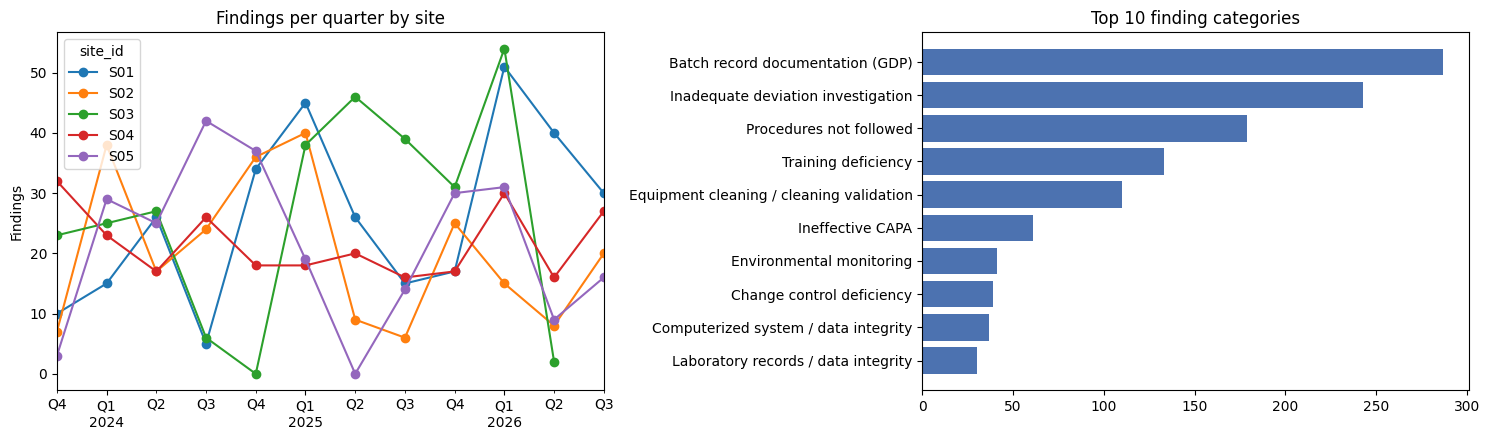

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

monthly = fa.set_index('audit_date').groupby('site_id').resample('QE')['finding_id'].count().unstack(0)
monthly.plot(ax=axes[0], marker='o')
axes[0].set_title('Findings per quarter by site'); axes[0].set_xlabel(''); axes[0].set_ylabel('Findings')

top10 = fa['category'].value_counts().head(10)[::-1]
axes[1].barh(top10.index, top10.values, color='#4C72B0')
axes[1].set_title('Top 10 finding categories')
plt.tight_layout(); plt.show()

## 11. Save to Google Drive

In [ ]:
for name, df in [('sites', sites), ('audits', audits), ('findings', findings), ('capas', capas)]:
    path = f'{RAW_DIR}/{name}.csv'
    df.to_csv(path, index=False, date_format='%Y-%m-%d')
    print(f'Saved {name:9s} {len(df):>5} rows → {path}')

Saved sites         5 rows → /content/drive/MyDrive/gmp-audit-risk-dashboard/data/raw/sites.csv
Saved audits      163 rows → /content/drive/MyDrive/gmp-audit-risk-dashboard/data/raw/audits.csv
Saved findings   1365 rows → /content/drive/MyDrive/gmp-audit-risk-dashboard/data/raw/findings.csv
Saved capas      1365 rows → /content/drive/MyDrive/gmp-audit-risk-dashboard/data/raw/capas.csv


## Next steps
1. Open `data/raw/` in Google Drive and spot-check a few rows of each CSV.
2. Paste the Section 9 numbers into Section 6 of `docs/data_dictionary.md`.
3. Save this notebook to GitHub: **File → Save a copy in GitHub** → `notebooks/01_generate_data.ipynb`.
4. Move on to Phase 3 (`02_risk_scoring`).